In [1]:
# IMPORTAR LIBRERÍAS

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [4]:
# Conectar con la cuenta de Google Drive con el entorno de Python

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# LEER ARCHIVO CSV

df_csv = pd.read_csv('/content/drive/MyDrive/data/frutas_5000_datos.csv')

# Mostrar primeras filas del CSV
print("DATOS CSV")
print(df_csv.head())


DATOS CSV
   ID    Fruta  Cantidad  Precio       Fecha
0   1   Banana        78   15.00  2025-06-14
1   2  Naranja        31    2.78  2026-05-20
2   3    Mango        47   13.03  2024-11-25
3   4     Pera        65    3.99  2024-07-30
4   5  Naranja        90    1.01  2025-03-03


In [8]:
# CREAR COLUMNA SurveyID
# Se crea una columna identificadora para poder unir el CSV con SQLite

df_csv["SurveyID"] = range(1, 5001)


In [9]:
# CONECTAR A SQLITE

conexion = sqlite3.connect('/content/drive/MyDrive/data/personas_frutas.sqlite')

cursor = conexion.cursor()


In [10]:
# LEER TABLA SQLITE

query = "SELECT * FROM personas_consumo_frutas"

df_sql = pd.read_sql_query(query, conexion)

# Mostrar primeras filas
print("\nDATOS SQLITE")
print(df_sql.head())



DATOS SQLITE
   SurveyID          Nombre  Edad             Ciudad FrutaFavorita  \
0         1     Emma Guzman    36     New Josephberg        Banana   
1         2     Isaac Smith    39  Port Randallmouth          Piña   
2         3    Julia Wilson    51       West Jessica         Mango   
3         4     Jorge Young    44       New Johnberg         Melón   
4         5  Francisco Page    28    Lake Davidmouth       Manzana   

   ConsumoSemanal  
0              18  
1               6  
2               9  
3              16  
4              12  


In [12]:
# REALIZA LA UNIÓN .CSV Y .SQLITE

# Se unen ambos DataFrames usando SurveyID; how='inner' Une únicamente coincidencias

df_unido = pd.merge(
    df_csv,
    df_sql,
    on="SurveyID",
    how="inner"
)

# Mostrar resultado
print("\nDATAFRAME UNIDO")
print(df_unido.head())

# GUARDAR EL MERGE EN SQLITE

df_unido.to_sql(
    "merge_frutas_personas",
    conexion,
    if_exists="replace",
    index=False
)

print("\nMERGE GUARDADO EN SQLITE")




DATAFRAME UNIDO
   ID    Fruta  Cantidad  Precio       Fecha  SurveyID          Nombre  Edad  \
0   1   Banana        78   15.00  2025-06-14         1     Emma Guzman    36   
1   2  Naranja        31    2.78  2026-05-20         2     Isaac Smith    39   
2   3    Mango        47   13.03  2024-11-25         3    Julia Wilson    51   
3   4     Pera        65    3.99  2024-07-30         4     Jorge Young    44   
4   5  Naranja        90    1.01  2025-03-03         5  Francisco Page    28   

              Ciudad FrutaFavorita  ConsumoSemanal  
0     New Josephberg        Banana              18  
1  Port Randallmouth          Piña               6  
2       West Jessica         Mango               9  
3       New Johnberg         Melón              16  
4    Lake Davidmouth       Manzana              12  

MERGE GUARDADO EN SQLITE


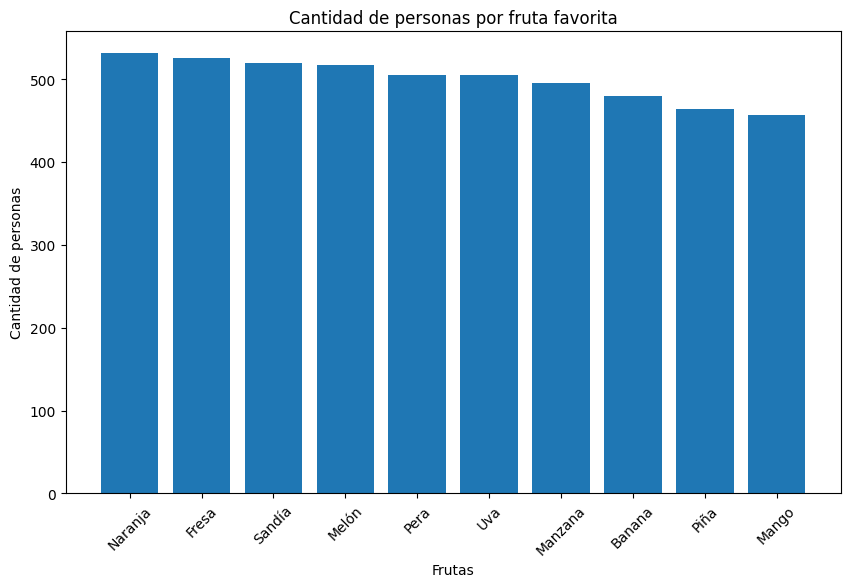

In [14]:
# GRÁFICO DE BARRAS DE CANTIDAD DE PERSONAS POR FRUTA FAVORITA

frutas_favoritas = df_unido["FrutaFavorita"].value_counts()

plt.figure(figsize=(10,6))

plt.bar(
    frutas_favoritas.index,
    frutas_favoritas.values
)

plt.title("Cantidad de personas por fruta favorita")

plt.xlabel("Frutas")

plt.ylabel("Cantidad de personas")

plt.xticks(rotation=45)

plt.show()


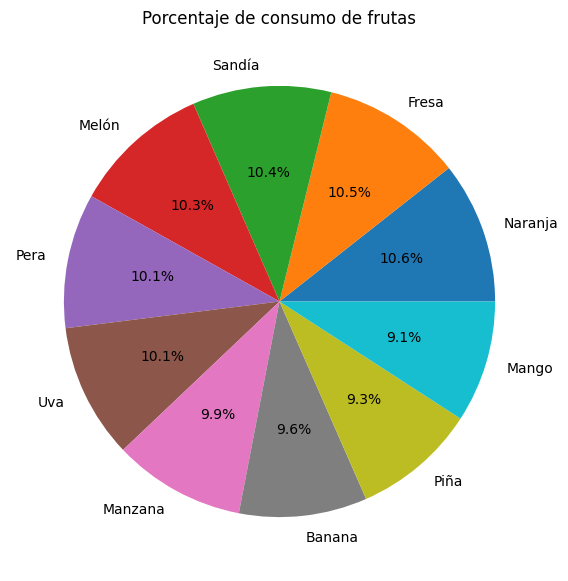

In [15]:
# GRÁFICO CIRCULAR DE PORCENTAJE DE CONSUMO DE FRUTAS

consumo = df_unido["FrutaFavorita"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    consumo.values,
    labels=consumo.index,
    autopct="%1.1f%%"
)

plt.title("Porcentaje de consumo de frutas")

plt.show()

In [16]:
# CONSULTAR TABLAS GUARDADAS

query_tablas = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tablas = pd.read_sql_query(query_tablas, conexion)

print("\nTABLAS EN SQLITE")
print(tablas)



TABLAS EN SQLITE
                      name
0  personas_consumo_frutas
1    merge_frutas_personas


In [17]:
# CONSULTAR DATOS DEL MERGE

query_merge = """
SELECT *
FROM merge_frutas_personas
LIMIT 5;
"""

resultado_merge = pd.read_sql_query(
    query_merge,
    conexion
)

print("\nDATOS DEL MERGE EN SQLITE")
print(resultado_merge)


DATOS DEL MERGE EN SQLITE
   ID    Fruta  Cantidad  Precio       Fecha  SurveyID          Nombre  Edad  \
0   1   Banana        78   15.00  2025-06-14         1     Emma Guzman    36   
1   2  Naranja        31    2.78  2026-05-20         2     Isaac Smith    39   
2   3    Mango        47   13.03  2024-11-25         3    Julia Wilson    51   
3   4     Pera        65    3.99  2024-07-30         4     Jorge Young    44   
4   5  Naranja        90    1.01  2025-03-03         5  Francisco Page    28   

              Ciudad FrutaFavorita  ConsumoSemanal  
0     New Josephberg        Banana              18  
1  Port Randallmouth          Piña               6  
2       West Jessica         Mango               9  
3       New Johnberg         Melón              16  
4    Lake Davidmouth       Manzana              12  


In [18]:
# EXPORTAR NUEVA BASE SQLITE

print("\nBASE DE DATOS SQLITE ACTUALIZADA")

conexion.close()


BASE DE DATOS SQLITE ACTUALIZADA
